<a href="https://colab.research.google.com/github/XhesBaze/AIclassificationAlgorithms/blob/main/Copy_of_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setting up the environment
The first step we take to train our models is to import all the needed libraries and set up a connection to our Google Drive where our dataset is located.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#import the necessary libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
import networkx as nx



#Importing the dataset from drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Data Preparation
During data preparation we load the data and save them in a variable.



In [ ]:
#reading the csv file
data = pd.read_csv("/content/drive/MyDrive/AI/Healthcare-Diabetes.csv", header =0)

#Seperate features from class
X = data.iloc[:,:-1]
#Creating an array named y, which contains the target data
y = data.iloc[:,-1]

## 3. Pre-Processing

During the preprocessing step, the raw data is first checked for any missing or null values, in case where we encounter an empty cell, that cell is filled with a default value or in our case we can just drop the cells since we have an abundance of records.

After handling empty cells, we eleminate any unecessary dimensinalities and make any needed transfornations so that our data is more organized.

Our dataset has only 9 features, however 'Id' is redundant in the presence of dataFrames so it can be removed.

All these steps set the stage up for building accurate and reliable models

In [ ]:
# Checking to see if there are any missing values in any of the columns
print(data.isnull().sum())

#There are no empty cells

#remove id
X = X.iloc[:,1:]

# Normalization

# 1. Min-Max Scaling
#scaler = MinMaxScaler()

# 2. Standard Scaling (Z-score normalization)
scaler = StandardScaler()

# Fit and transform the data using the scaler
data_features_normalized = scaler.fit_transform(X)

# Convert the normalized array back to a DataFrame (if needed)
X = pd.DataFrame(data_features_normalized, columns= X.columns)

Id                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Data Distribution
Data distribution helps us visualize if our dataset is balanced or not.

In our case the dataset has more instances of diabetes presence than absence, thus we can say that this dataset it imbalanced.

Having an imbalanced class distribution in the 'Outcome; feature can pose challenges in the machine learning models, but it's not necessarily always an issue.


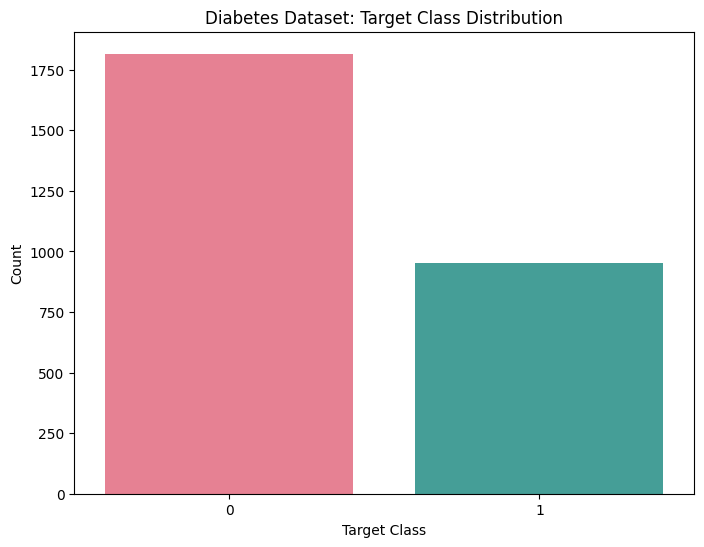


Individuals without diabetes:  1816
Individuals with diabetes:  952


In [ ]:
# Count the number of instances for each class
class_counts = y.value_counts()

# Define a custom color palette for the classes
custom_palette = sns.color_palette("husl", len(class_counts))


# Create a bar plot with custom colors
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=custom_palette)
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.title('Diabetes Dataset: Target Class Distribution')
plt.show()


print("\nIndividuals without diabetes: ", class_counts[0])
print("Individuals with diabetes: ", class_counts[1])


## Splitting the data

In [ ]:
#20% of the data will be used for testing
#80% will be used for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Building Classification Models

### 1. Logistic Regression

In [ ]:
#Start timer
start_time_LR = time.time()

#Set up the logistic regression classifier
logistic_reg = LogisticRegression(random_state = 42)

#Model Training and Predictions
logistic_reg.fit(X_train, y_train)

#After the classifier is trained, we make the predictions on the test data
y_pred_LR = logistic_reg.predict(X_test)

#Model Evaluation

accuracy_LR = accuracy_score(y_test, y_pred_LR)
precision_LR = precision_score(y_test, y_pred_LR, average='weighted')
recall_LR = recall_score(y_test, y_pred_LR, average='weighted')
f1_LR = f1_score(y_test, y_pred_LR, average='weighted')

# Calculate Mean Absolute Error
mae_LR = mean_absolute_error(y_test, y_pred_LR)

end_time_LR = time.time()
time_LR = end_time_LR - start_time_LR

print('Logistic Regression - Accuracy  : %.2f' % (accuracy_LR * 100), '%')
print('Logistic Regression - Precision : %.2f' % (precision_LR * 100), '%')
print('Logistic Regression - Recall    : %.2f' % (recall_LR * 100), '%')
print('Logistic Regression - F1-Score  : %.2f' % (f1_LR * 100), '%')
print('Logistic Regression - MAE       : %.2f' % mae_LR)
print('Logistic Regression - Time Taken : %.2f' % time_LR, 'seconds')

#Confusion Matrix
print("\n Logistic Regression Classification:")
conf_matrix = confusion_matrix(y_pred_LR,y_test )
print(conf_matrix)
print(classification_report(y_pred_LR,y_test))

Logistic Regression - Accuracy  : 77.44 %
Logistic Regression - Precision : 76.89 %
Logistic Regression - Recall    : 77.44 %
Logistic Regression - F1-Score  : 76.33 %
Logistic Regression - MAE       : 0.23
Logistic Regression - Time Taken : 0.14 seconds

 Logistic Regression Classification:
[[331  89]
 [ 36  98]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       420
           1       0.52      0.73      0.61       134

    accuracy                           0.77       554
   macro avg       0.71      0.76      0.73       554
weighted avg       0.81      0.77      0.79       554



Observing different results based on different test_sizes

In [ ]:
# Pre-defined test sizes
test_sizes = [0.2, 0.3, 0.4]


# Loop through different test sizes
for i, test_size in enumerate(test_sizes):
    print("For test size: ",test_size)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    accuracy_scores = []
    n_values = []

    logistic_reg = LogisticRegression(random_state=42)

    logistic_reg.fit(X_train, y_train)

    y_pred = logistic_reg.predict(X_test)

    accuracy_LR = accuracy_score(y_test, y_pred)
    precision_LR = precision_score(y_test, y_pred, average='weighted')
    recall_LR = recall_score(y_test, y_pred, average='weighted')
    f1_LR = f1_score(y_test, y_pred, average='weighted')

    # Calculate Mean Absolute Error
    mae_LR = mean_absolute_error(y_test, y_pred)

    print('Logistic Regression - Accuracy  : %.2f' % (accuracy_LR * 100), '%')
    print('Logistic Regression - Precision : %.2f' % (precision_LR * 100), '%')
    print('Logistic Regression - Recall    : %.2f' % (recall_LR * 100), '%')
    print('Logistic Regression - F1-Score  : %.2f' % (f1_LR * 100), '%')
    print('Logistic Regression - MAE       : %.2f' % mae_LR,'\n')


For test size:  0.2
Logistic Regression - Accuracy  : 77.44 %
Logistic Regression - Precision : 76.89 %
Logistic Regression - Recall    : 77.44 %
Logistic Regression - F1-Score  : 76.33 %
Logistic Regression - MAE       : 0.23 

For test size:  0.3
Logistic Regression - Accuracy  : 78.82 %
Logistic Regression - Precision : 78.20 %
Logistic Regression - Recall    : 78.82 %
Logistic Regression - F1-Score  : 77.93 %
Logistic Regression - MAE       : 0.21 

For test size:  0.4
Logistic Regression - Accuracy  : 77.62 %
Logistic Regression - Precision : 77.11 %
Logistic Regression - Recall    : 77.62 %
Logistic Regression - F1-Score  : 76.56 %
Logistic Regression - MAE       : 0.22 



Test size 0.3 seems to be the best split.

### 2. Random Forest Classifier

In [ ]:
start_time_RFC = time.time()

random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
)
random_forest.fit(X_train, y_train)

y_pred_RF = random_forest.predict(X_test)


accuracy_RFC = accuracy_score(y_test, y_pred_RF)
precision_RFC = precision_score(y_test, y_pred_RF, average='weighted')
recall_RFC = recall_score(y_test, y_pred_RF, average='weighted')
f1_RFC = f1_score(y_test, y_pred_RF, average='weighted')

# Calculate Mean Absolute Error
mae_RF = mean_absolute_error(y_test, y_pred_RF)

end_time_RFC = time.time()
time_RFC = end_time_RFC - start_time_RFC

print('Random Forest Classifier - Accuracy  : %.2f' % (accuracy_RFC*100), '%')
print('Random Forest Classifier - Precision : %.2f' % (precision_RFC*100), '%')
print('Random Forest Classifier - Recall    : %.2f' % (recall_RFC*100), '%')
print('Random Forest Classifier - F1        : %.2f' % (f1_RFC*100), '%')
print('Random Forest - MAE       : %.2f' % mae_RF)
print('Random Forest Classifier - Time Taken : %.2f' % time_RFC, 'seconds')


print("\n Random Forest Classification:")
print(confusion_matrix(y_pred_RF, y_test))
print(classification_report(y_pred_RF, y_test))

Random Forest Classifier - Accuracy  : 98.19 %
Random Forest Classifier - Precision : 98.20 %
Random Forest Classifier - Recall    : 98.19 %
Random Forest Classifier - F1        : 98.19 %
Random Forest - MAE       : 0.02
Random Forest Classifier - Time Taken : 0.41 seconds

 Random Forest Classification:
[[364   7]
 [  3 180]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       371
           1       0.96      0.98      0.97       183

    accuracy                           0.98       554
   macro avg       0.98      0.98      0.98       554
weighted avg       0.98      0.98      0.98       554



Observing different results on different test sizes

Test Size: 0.2, Accuracy: 0.98
Random Forest - MAE       : 0.02
Test Size: 0.3, Accuracy: 0.98
Random Forest - MAE       : 0.02
Test Size: 0.4, Accuracy: 0.97
Random Forest - MAE       : 0.03




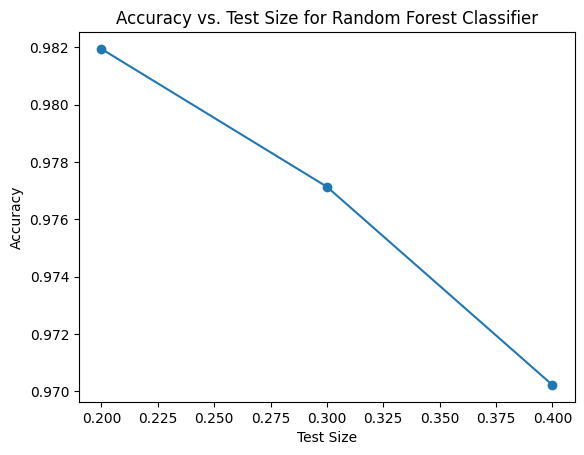

In [ ]:

test_sizes = [0.2, 0.3, 0.4]  # Vary test size from 10% to 50% in increments of 10%
accuracy_values = []

for test_size in test_sizes:
    # Split the data into training and testing sets with the current test size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Train the Random Forest model
    random_forest = RandomForestClassifier(n_estimators=100, criterion='gini')
    random_forest.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_RF = random_forest.predict(X_test)

    # Calculate accuracy and store it
    accuracy = accuracy_score(y_test, y_pred_RF)
    accuracy_values.append(accuracy)

    # Calculate Mean Absolute Error
    mae_RF = mean_absolute_error(y_test, y_pred_RF)

    print(f'Test Size: {test_size}, Accuracy: {accuracy:.2f}')
    print('Random Forest - MAE       : %.2f' % mae_RF)


print("\n")
# Plotting the results
plt.plot(test_sizes, accuracy_values, marker='o')
plt.title('Accuracy vs. Test Size for Random Forest Classifier')
plt.xlabel('Test Size')
plt.ylabel('Accuracy')
plt.show()


Observing different results on different test sizes for different number of trees

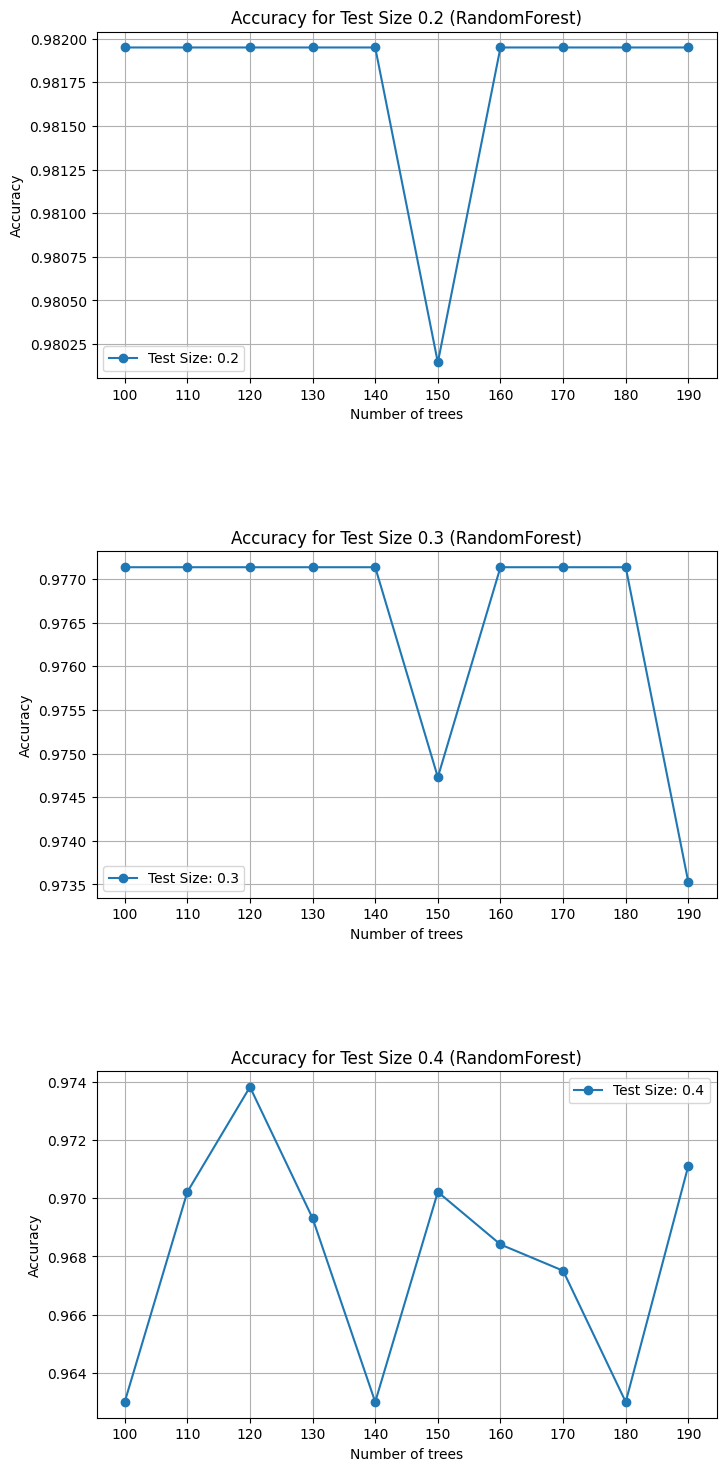

In [ ]:
# Pre-defined test sizes
test_sizes = [0.2, 0.3, 0.4]

# Creating a grid of subplots
fig, axs = plt.subplots(len(test_sizes), 1, figsize=(8, 6 * len(test_sizes)))

# Loop through different test sizes
for i, test_size in enumerate(test_sizes):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    accuracy_scores = []
    n_values = []

    # Loop through different values of number of trees
    for n in range(100, 200, 10):
        random_forest = RandomForestClassifier(
            n_estimators=n,
            criterion='gini',
          )

        random_forest.fit(X_train, y_train)

        y_pred = random_forest.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores.append(accuracy)
        n_values.append(n)

        #print(n, " " ,accuracy)

  # Plotting accuracy for the current test size on a separate subplot
    axs[i].plot(n_values, accuracy_scores, marker='o', linestyle='-', label=f'Test Size: {test_size}')
    axs[i].set_title(f'Accuracy for Test Size {test_size} (RandomForest)')
    axs[i].set_xlabel('Number of trees')
    axs[i].set_ylabel('Accuracy')
    axs[i].set_xticks(n_values)
    axs[i].grid(True)
    axs[i].legend()


# Adjusting the space between subplots
plt.subplots_adjust(hspace=0.5)
plt.show()

### 3. KNN

After preprocessing we train a model using the training data that we prepped before. We then conclude a test to see how accurate its predictions are with the test data, and check if it learned properly.


To better understand how our model functions and how different parameter changes lead to different outcomes we can use python to visualize these changes for a better understanding.

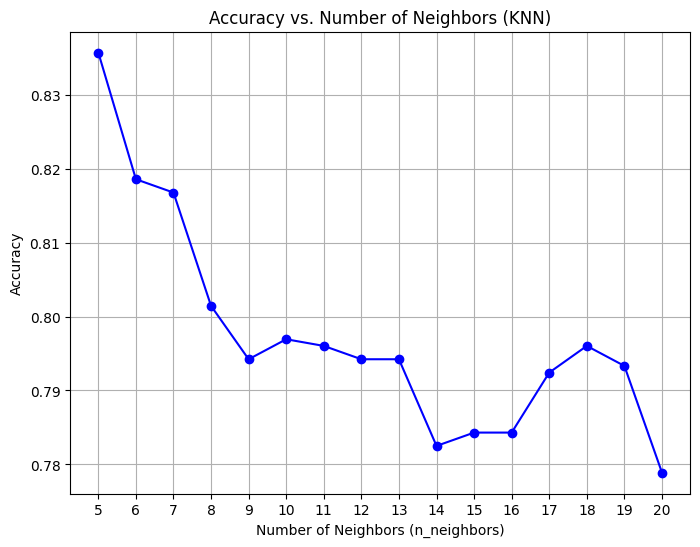

In [ ]:
accuracy_scores = []
n_values = []

for n in range(5, 21):
    # Initializing the K-Nearest Neighbors (KNN) classifier with number n for nearest neighbors.
    knn = KNeighborsClassifier(n_neighbors=n)

    # Training the KNN model
    knn.fit(X_train, y_train)

    # Predict on the test set
    y_pred = knn.predict(X_test)

    # Calculate accuracy and appending accuracy and n_neighbors values to lists
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    n_values.append(n)

    #print(n, " " ,accuracy)

# Plotting the accuracy scores for different n_neighbors values
plt.figure(figsize=(8, 6))
plt.plot(n_values, accuracy_scores, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Number of Neighbors (KNN)')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Accuracy')
plt.xticks(n_values)
plt.grid(True)
plt.show()

Here we can see that with the test size set to 20% the best outcome would be to set n nearest neigbor to the value 5.

But what if we have a change in the test size?

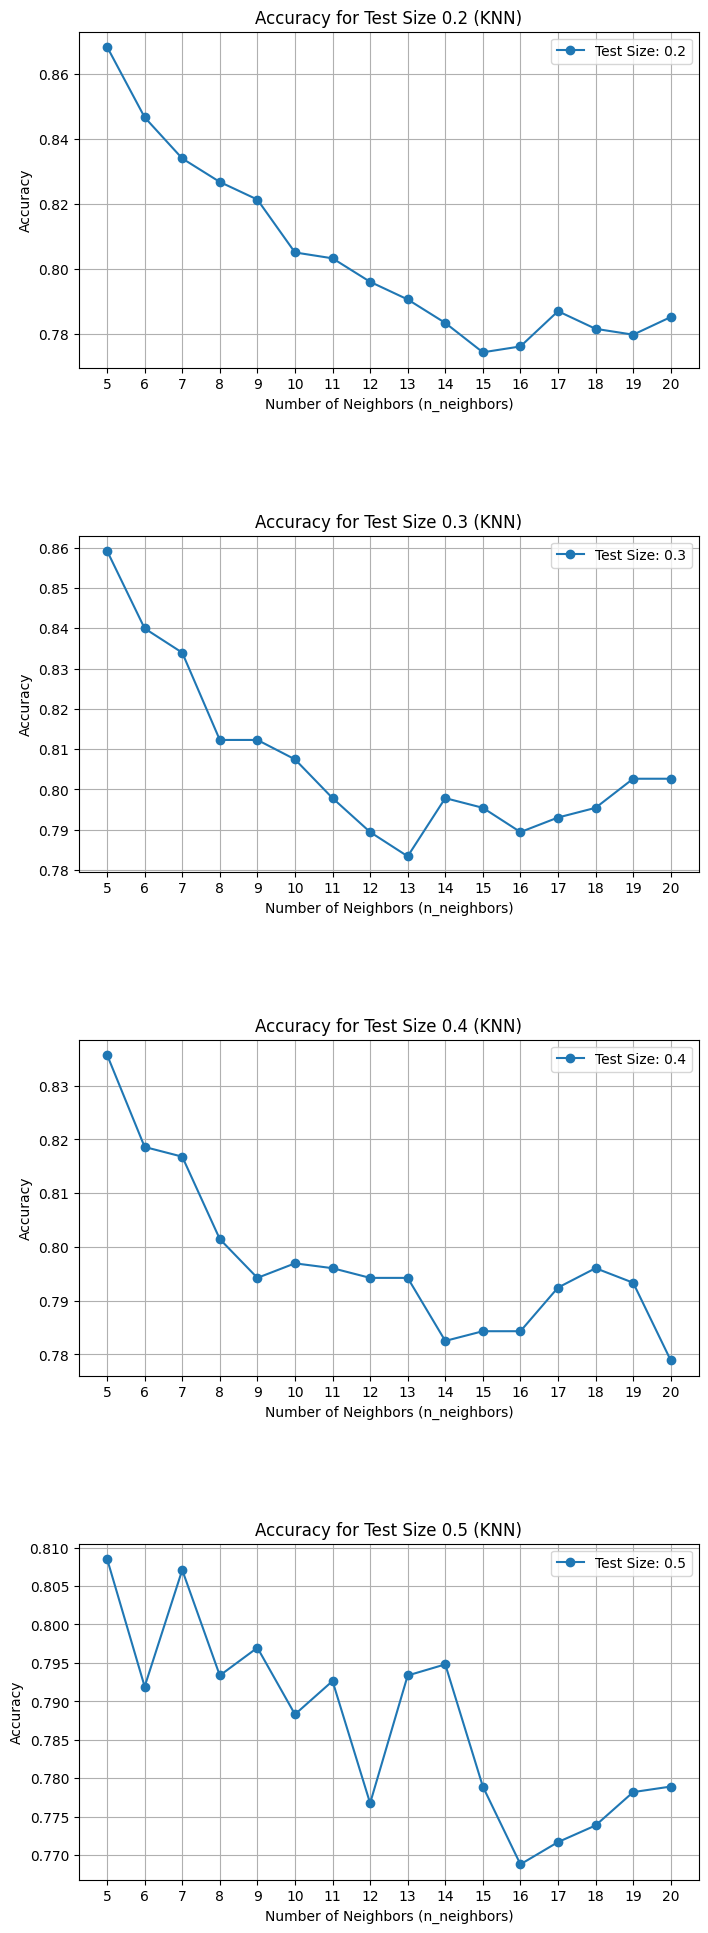

In [ ]:
# Pre-defined test sizes
test_sizes = [0.2, 0.3, 0.4, 0.5]

# Creating a grid of subplots
fig, axs = plt.subplots(len(test_sizes), 1, figsize=(8, 6 * len(test_sizes)))

# Loop through different test sizes
for i, test_size in enumerate(test_sizes):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    accuracy_scores = []
    n_values = []

    # Loop through different values of n_neighbors
    for n in range(5, 21):
        knn = KNeighborsClassifier(n_neighbors=n)

        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores.append(accuracy)
        n_values.append(n)

        #print(n, " " ,accuracy)

  # Plotting accuracy for the current test size on a separate subplot
    axs[i].plot(n_values, accuracy_scores, marker='o', linestyle='-', label=f'Test Size: {test_size}')
    axs[i].set_title(f'Accuracy for Test Size {test_size} (KNN)')
    axs[i].set_xlabel('Number of Neighbors (n_neighbors)')
    axs[i].set_ylabel('Accuracy')
    axs[i].set_xticks(n_values)
    axs[i].grid(True)
    axs[i].legend()

# Adjusting the space between subplots
plt.subplots_adjust(hspace=0.5)
plt.show()

Test size 20% seems to be the best choice for accuracy.

KNN - Accuracy  : 86.82 %
KNN - Precision : 87.02 %
KNN - Recall    : 86.82 %
KNN - F1-Score  : 86.90 %
KNN - MAE       : 0.13
KNN - Time Taken : 0.06 seconds




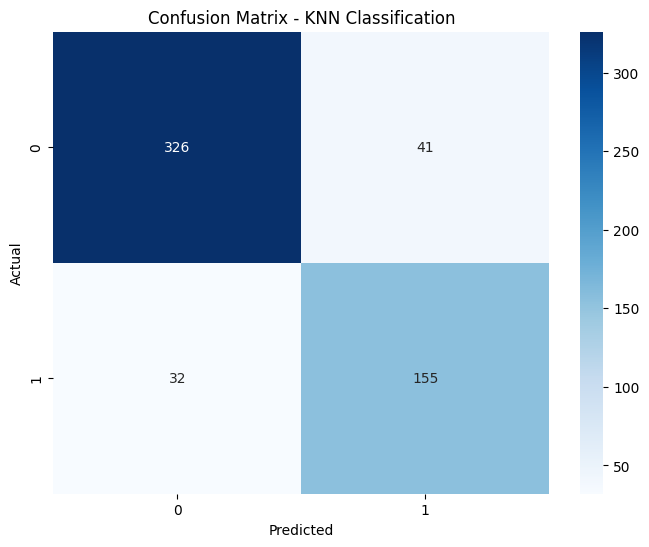

In [ ]:
#Start timer
start_time_KNN = time.time()

# Initializing the K-Nearest Neighbors (KNN) classifier with number 5 for nearest neighbors.
KNN = KNeighborsClassifier(n_neighbors=5)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the KNN model
KNN.fit(X_train, y_train)

# Making predictions and caluclating its accuracy
y_pred_KNN = KNN.predict(X_test)

accuracy_KNN = accuracy_score(y_test, y_pred_KNN)
precision_KNN = precision_score(y_test, y_pred_KNN, average='weighted')
recall_KNN = recall_score(y_test, y_pred_KNN, average='weighted')
f1_KNN = f1_score(y_test, y_pred_KNN, average='weighted')

# Calculate Mean Absolute Error
mae_KNN = mean_absolute_error(y_test,y_pred_KNN)

end_time_KNN = time.time()
time_KNN = end_time_KNN - start_time_KNN

print('KNN - Accuracy  : %.2f' % (accuracy_KNN * 100), '%')
print('KNN - Precision : %.2f' % (precision_KNN * 100), '%')
print('KNN - Recall    : %.2f' % (recall_KNN * 100), '%')
print('KNN - F1-Score  : %.2f' % (f1_KNN * 100), '%')
print('KNN - MAE       : %.2f' % mae_KNN)
print('KNN - Time Taken : %.2f' % time_KNN, 'seconds')

print('\n')

conf_matrix = confusion_matrix(y_test, y_pred_KNN)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 4. K-Means

K-means clustering requires us to select  the number of clusters we want to group the data into (K).

A method to find the optimal 'K' is the 'Elbow Method'. The elbow method lets us graph the sum of squares within a cluster to different values of K. After doing that wr look for an 'elbow' point where the rate of decrease sharply changes.



In our case we need to cluster diabetes and non-diabetes, thus the optimal value for ‘K’ would be 2.

Now to display our clusters we will first create a heat map that will show which of the features has more weight on the 'Outcome'

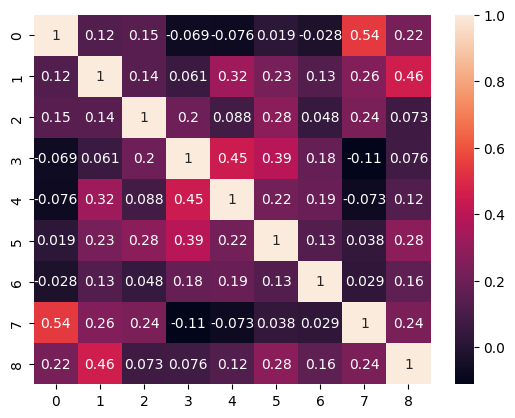

In [ ]:
dataset_new = data.iloc[:,1:]

sc = StandardScaler()

dataset_scaled = sc.fit_transform(dataset_new)

data1 = pd.DataFrame(dataset_scaled)
data1

sns.heatmap(data1.corr(), annot = True)
plt.show()

Here we can see that the features that have the most weight on the 'Outcome' are 'Glucose' and 'BMI' and use K-means with the value of ‘K’ set to 2 to discover the clusters in our dataset.

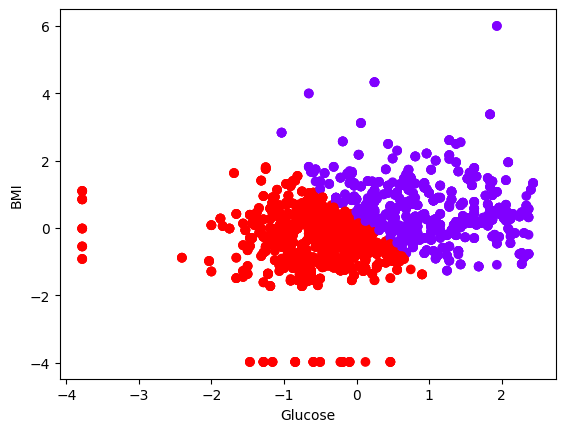

In [ ]:
# Selecting features - [Glucose, BMI]
X = data1.iloc[:, [1, 5]].values
Y = data1.iloc[:, 8].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 42, stratify = dataset_new['Outcome'] )

KMeans_Clustering = KMeans(n_clusters =2, random_state=0, n_init=10)
KMeans_Clustering.fit(X)

plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.scatter(data1.iloc[:, [1]].values,data1.iloc[:, [5]].values, c=KMeans_Clustering.labels_, cmap='rainbow')



You may be wondering, why do we go far to find if our model works correctly, why don't we use something simple?

Well, since K-means is an unsupervised algorithm it does not predict class labels like a classifier does, so it doesn't have "true" labels to compare with predicted labels. Because of that confusion matrixes and classification reports are not good ways to evaulate this model.

So if we were to use one of those methods we would get outcomes like this.

Confusion Matrix :


<Axes: >

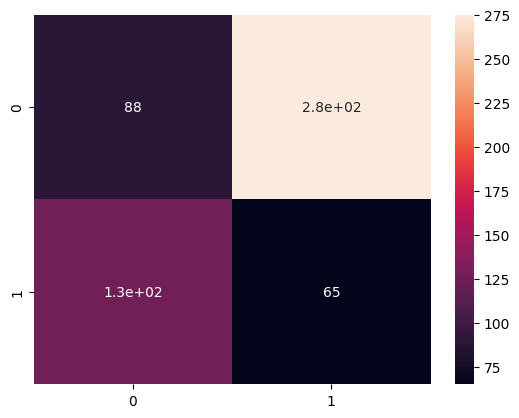

In [ ]:
# Prediction using kmeans
kpred = KMeans_Clustering.predict(X_test)

threshold = 0.5
Y_test_binary = np.where(Y_test > threshold, 1, 0)


print("Confusion Matrix :")
outcome_labels = sorted(data.Outcome.unique())
sns.heatmap(
    confusion_matrix(Y_test_binary, kpred),
    annot=True,
    xticklabels=outcome_labels,
    yticklabels=outcome_labels
)

### 5. Decision Tree

In [ ]:
decisionTree_classifier = DecisionTreeClassifier(random_state=42)

decisionTree_classifier.fit(X_train, y_train)

y_pred = decisionTree_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_DT = mean_absolute_error(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('MAE       : %.2f' % mae_DT)


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       367
           1       0.98      0.96      0.97       187

    accuracy                           0.98       554
   macro avg       0.98      0.98      0.98       554
weighted avg       0.98      0.98      0.98       554

Confusion Matrix:
 [[363   4]
 [  7 180]]
Accuracy: 0.98014440433213
Precision: 0.9782608695652174
Recall: 0.9625668449197861
F1 Score: 0.9703504043126684
MAE       : 0.02


**Visualization**

A legend to the visualized tree:

***1.Orange nodes:*** Represent decision nodes
Decision nodes are points in the decision tree where the algorithm makes a decision based on a specific feature or condition.

***2.Blue nodes:*** These represent leaf nodes and indicate the predicted class.
Leaf nodes are endpoints in the decision tree where the final decision or prediction is made.

The intensity of the colors may vary based on the number of samples for each class in that node.

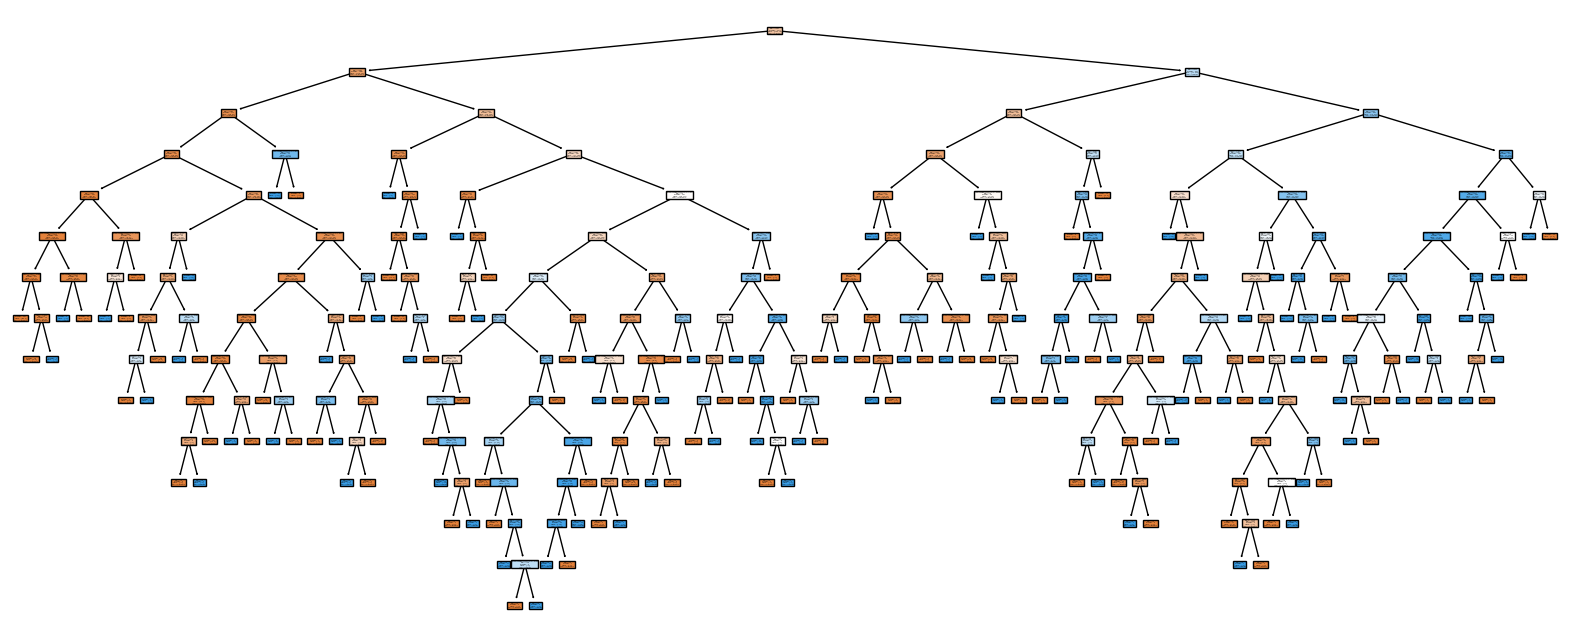

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(decisionTree_classifier, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.show()


***Trying different test sizes***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

decisionTree_classifier = DecisionTreeClassifier(random_state=42)

decisionTree_classifier.fit(X_train, y_train)

y_pred = decisionTree_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_DT = mean_absolute_error(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('MAE       : %.2f' % mae_DT)


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       562
           1       0.94      0.97      0.95       269

    accuracy                           0.97       831
   macro avg       0.96      0.97      0.97       831
weighted avg       0.97      0.97      0.97       831

Confusion Matrix:
 [[545  17]
 [  8 261]]
Accuracy: 0.9699157641395909
Precision: 0.9388489208633094
Recall: 0.9702602230483272
F1 Score: 0.9542961608775138
MAE       : 0.03


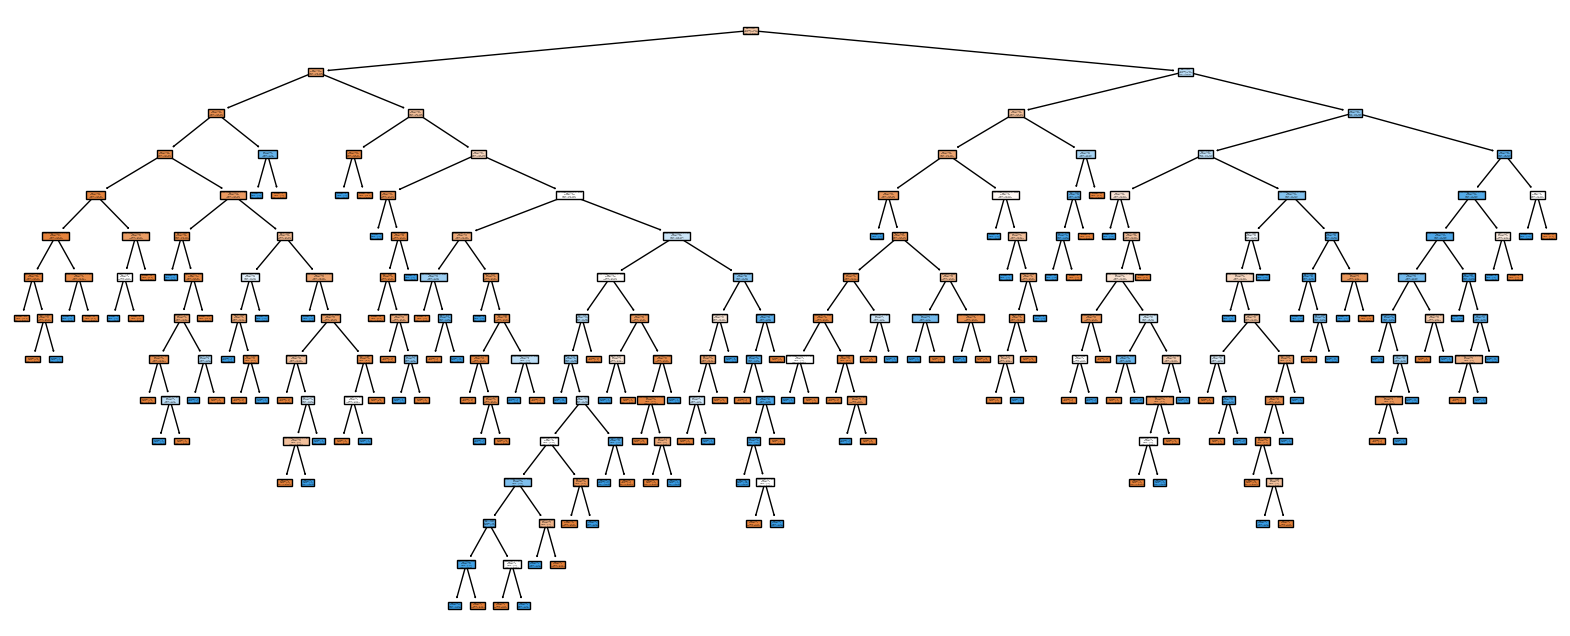

In [ ]:
plt.figure(figsize=(20,8))
plot_tree(decisionTree_classifier, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

decisionTree_classifier = DecisionTreeClassifier(random_state=42)

decisionTree_classifier.fit(X_train, y_train)

y_pred = decisionTree_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_DT = mean_absolute_error(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('MAE       : %.2f' % mae_DT)


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       732
           1       0.95      0.94      0.94       376

    accuracy                           0.96      1108
   macro avg       0.96      0.96      0.96      1108
weighted avg       0.96      0.96      0.96      1108

Confusion Matrix:
 [[712  20]
 [ 23 353]]
Accuracy: 0.9611913357400722
Precision: 0.9463806970509383
Recall: 0.9388297872340425
F1 Score: 0.9425901201602136
MAE       : 0.04


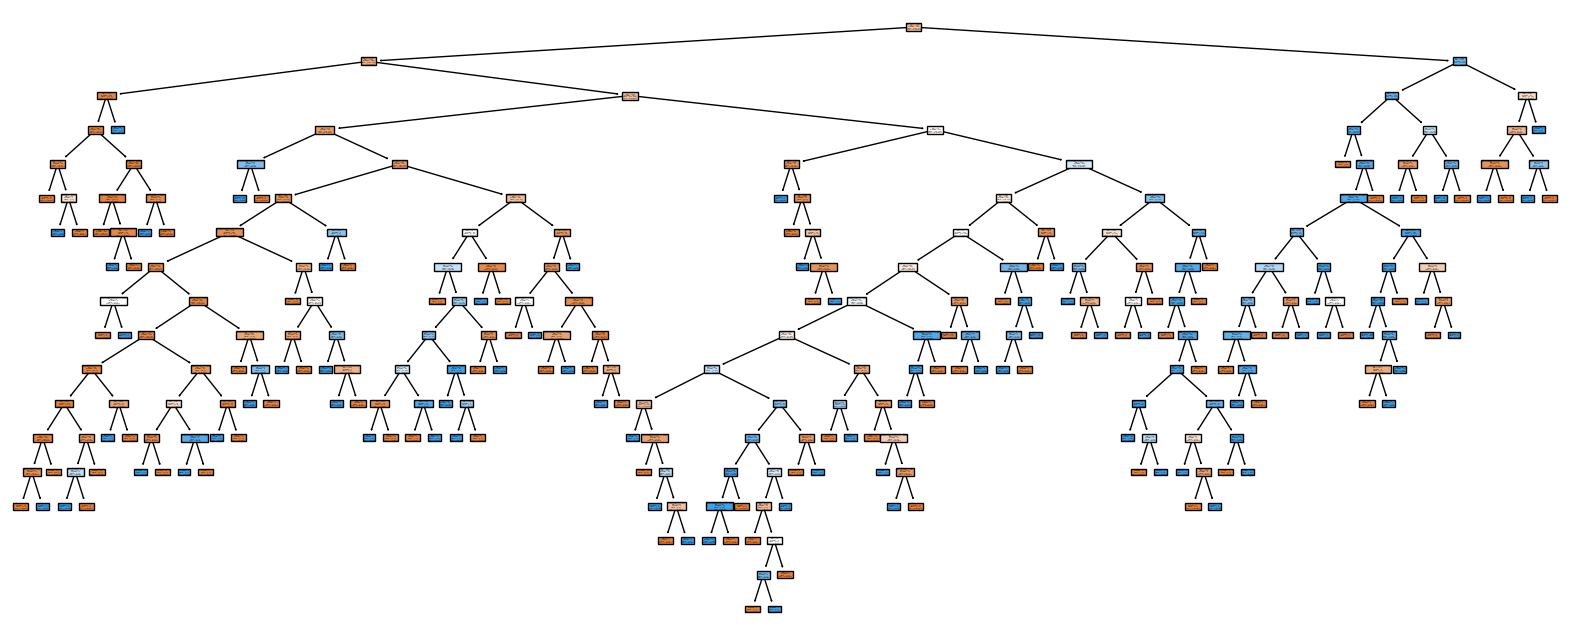

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(decisionTree_classifier, filled=True, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'])
plt.show()

### 6. Neural Networks

In [ ]:
import numpy as np
import plotly.graph_objects as go

nn_model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])


nn_model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model1.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)


nn_pred = (nn_model1.predict(X_test) > 0.5).astype("int32")

# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred)

nn_conf_matrix1 = confusion_matrix(y_test, nn_pred)
nn_classification_report1 = classification_report(y_test, nn_pred)


print("Neural Network Classification Report:\n", nn_classification_report1)
print('Neural Network - MAE       : %.2f' % mae_NN)


weights = []
for layer in nn_model1.layers:
    weights.append(layer.get_weights()[0])

fig = go.Figure()

for i, layer_weights in enumerate(weights):
    num_nodes_in = layer_weights.shape[0]
    num_nodes_out = layer_weights.shape[1]

    x_vals = np.repeat(i, num_nodes_in)
    y_vals = np.arange(1, num_nodes_in + 1)
    z_vals = np.arange(1, num_nodes_out + 1)

    for j in range(num_nodes_out):
        fig.add_trace(go.Scatter3d(
            x=x_vals,
            y=y_vals,
            z=np.repeat(z_vals[j], num_nodes_in),
            mode='markers',
            marker=dict(
                size=np.abs(layer_weights[:, j]) * 20,
                color=layer_weights[:, j],
                colorscale='Viridis',
                opacity=0.8
            ),
            name=f'Layer {i + 1} Node {j + 1}'
        ))

fig.update_layout(scene=dict(
                    xaxis_title='Layer',
                    yaxis_title='Node (Incoming)',
                    zaxis_title='Node (Outgoing)'),
                    width=800, height=800,
                    margin=dict(l=0, r=0, b=0, t=0))
fig.show()


35/35 [==============================] - 0s 1ms/step
Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       732
           1       0.74      0.60      0.67       376

    accuracy                           0.79      1108
   macro avg       0.78      0.75      0.76      1108
weighted avg       0.79      0.79      0.79      1108

Neural Network - MAE       : 0.21


***Changing the validation split***

35/35 [==============================] - 0s 5ms/step
Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       732
           1       0.75      0.62      0.68       376

    accuracy                           0.80      1108
   macro avg       0.79      0.76      0.77      1108
weighted avg       0.80      0.80      0.80      1108

Neural Network - MAE       : 0.20


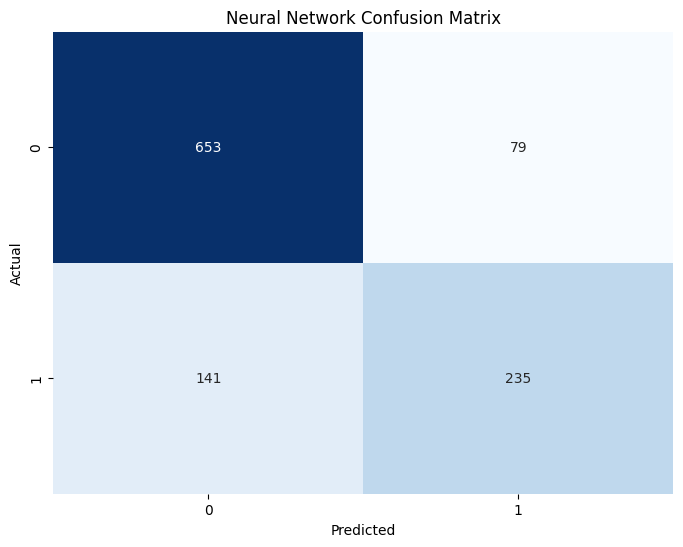

In [ ]:
nn_model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

nn_pred = (nn_model2.predict(X_test) > 0.5).astype("int32")

# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred)


nn_conf_matrix2 = confusion_matrix(y_test, nn_pred)

nn_classification_report2 = classification_report(y_test, nn_pred)
print("Neural Network Classification Report:\n", nn_classification_report2)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix2, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

35/35 [==============================] - 0s 1ms/step
Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       732
           1       0.72      0.59      0.65       376

    accuracy                           0.79      1108
   macro avg       0.77      0.74      0.75      1108
weighted avg       0.78      0.79      0.78      1108

Neural Network - MAE       : 0.21


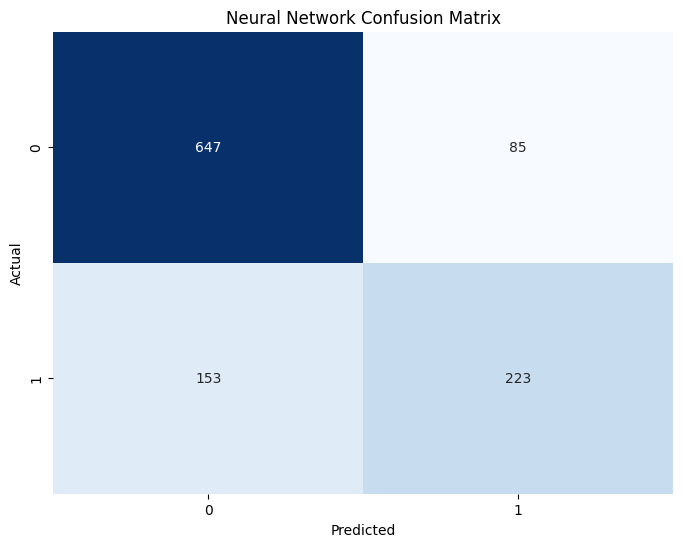

In [ ]:

nn_model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model3.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.3, verbose=0)

nn_pred = (nn_model3.predict(X_test) > 0.5).astype("int32")
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred)

nn_conf_matrix3 = confusion_matrix(y_test, nn_pred)

nn_classification_report3 = classification_report(y_test, nn_pred)
print("Neural Network Classification Report:\n", nn_classification_report3)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix3, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


***Changing the features of the model***

18/18 [==============================] - 0s 8ms/step
Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       367
           1       0.76      0.75      0.76       187

    accuracy                           0.84       554
   macro avg       0.82      0.82      0.82       554
weighted avg       0.84      0.84      0.84       554

Neural Network - MAE       : 0.16


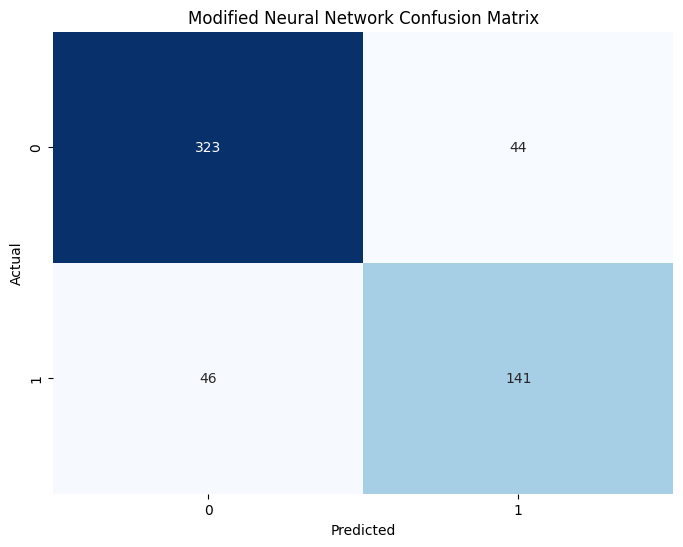

In [ ]:
nn_model_11 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_11.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_11.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

nn_pred_modified = (nn_model_11.predict(X_test) > 0.5).astype("int32")
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_modified)

nn_conf_matrix_11 = confusion_matrix(y_test, nn_pred_modified)

nn_classification_report_modified = classification_report(y_test, nn_pred_modified)
print("Modified Neural Network Classification Report:\n", nn_classification_report_modified)
print('Neural Network - MAE       : %.2f' % mae_NN)


plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_11, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

18/18 [==============================] - 0s 2ms/step
Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.88       367
           1       0.82      0.67      0.74       187

    accuracy                           0.84       554
   macro avg       0.83      0.80      0.81       554
weighted avg       0.84      0.84      0.83       554

Neural Network - MAE       : 0.16


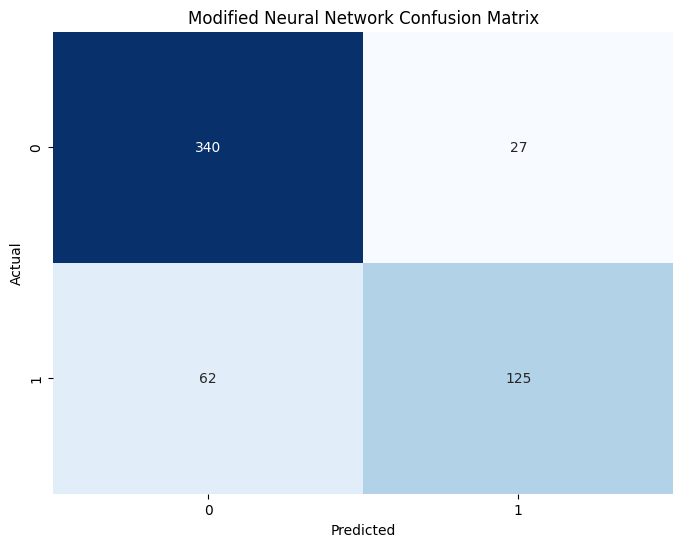

In [ ]:
nn_model_12 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_12.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_12.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

nn_pred_12 = (nn_model_12.predict(X_test) > 0.5).astype("int32")
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_12)

nn_conf_matrix_12 = confusion_matrix(y_test, nn_pred_12)

nn_classification_report_12 = classification_report(y_test, nn_pred_12)
print("Modified Neural Network Classification Report:\n", nn_classification_report_12)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_12, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

18/18 [==============================] - 0s 2ms/step
Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       367
           1       0.74      0.69      0.71       187

    accuracy                           0.81       554
   macro avg       0.79      0.78      0.79       554
weighted avg       0.81      0.81      0.81       554

Neural Network - MAE       : 0.19


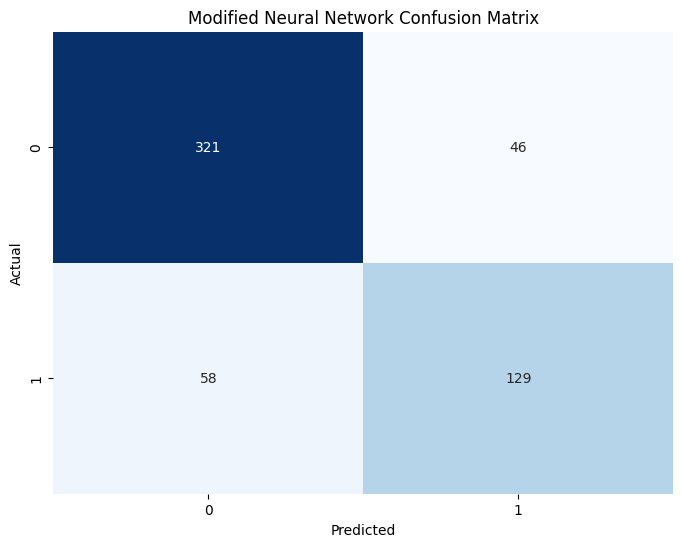

In [ ]:
nn_model_13 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_13.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_13.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.3, verbose=0)

nn_pred_13 = (nn_model_13.predict(X_test) > 0.5).astype("int32")
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_13)


nn_conf_matrix_13 = confusion_matrix(y_test, nn_pred_13)

nn_classification_report_13 = classification_report(y_test, nn_pred_13)
print("Modified Neural Network Classification Report:\n", nn_classification_report_13)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_13, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

***Changing them once more***

18/18 [==============================] - 0s 5ms/step
Another Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       367
           1       0.78      0.85      0.82       187

    accuracy                           0.87       554
   macro avg       0.85      0.87      0.86       554
weighted avg       0.87      0.87      0.87       554

Neural Network - MAE       : 0.13


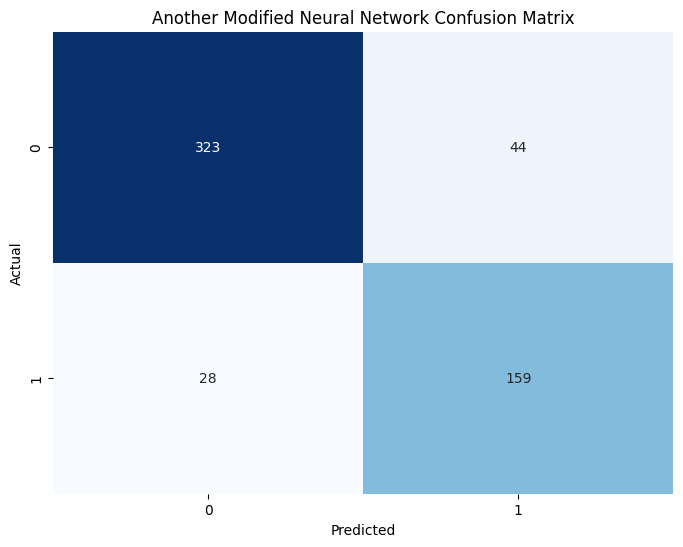

In [ ]:
nn_model_21 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_21.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_21.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

nn_pred_21 = (nn_model_21.predict(X_test) > 0.5).astype("int32")

nn_conf_matrix_21 = confusion_matrix(y_test, nn_pred_21)
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_21)


nn_classification_report_another_modified = classification_report(y_test, nn_pred_21)
print("Another Modified Neural Network Classification Report:\n", nn_classification_report_another_modified)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_21, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Another Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

18/18 [==============================] - 0s 5ms/step
Another Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90       367
           1       0.82      0.80      0.81       187

    accuracy                           0.87       554
   macro avg       0.86      0.85      0.86       554
weighted avg       0.87      0.87      0.87       554

Neural Network - MAE       : 0.13


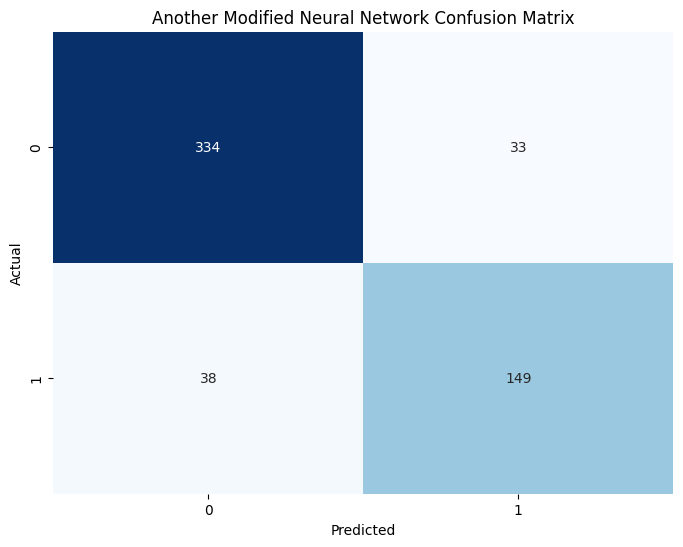

In [ ]:
nn_model_22 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_22.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_22.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

nn_pred_22 = (nn_model_22.predict(X_test) > 0.5).astype("int32")

nn_conf_matrix_another_modified = confusion_matrix(y_test, nn_pred_22)

# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_22)


nn_classification_report_22 = classification_report(y_test, nn_pred_22)
print("Another Modified Neural Network Classification Report:\n", nn_classification_report_22)
print('Neural Network - MAE       : %.2f' % mae_NN)


plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_another_modified, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Another Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

18/18 [==============================] - 1s 7ms/step
Another Modified Neural Network Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       367
           1       0.78      0.85      0.82       187

    accuracy                           0.87       554
   macro avg       0.85      0.87      0.86       554
weighted avg       0.87      0.87      0.87       554

Neural Network - MAE       : 0.14


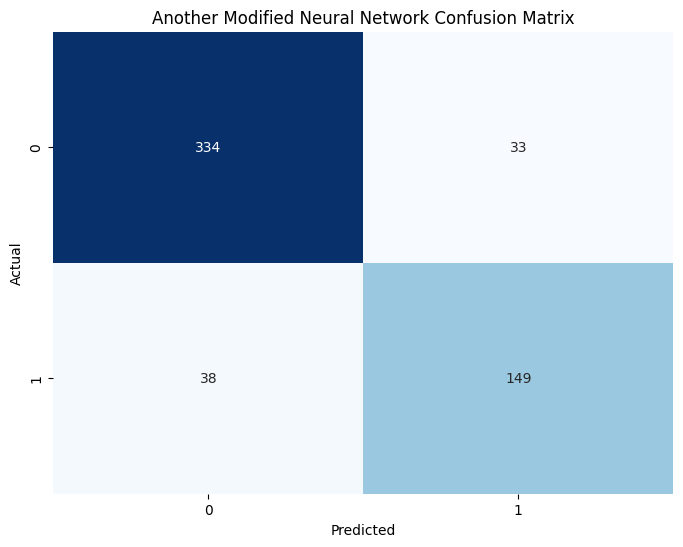

In [ ]:
nn_model_23 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification, so using sigmoid activation
])

nn_model_23.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_23.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.3, verbose=0)

nn_pred_23= (nn_model_23.predict(X_test) > 0.5).astype("int32")

nn_conf_matrix_23 = confusion_matrix(y_test, nn_pred_23)

# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_23)

nn_classification_report_23 = classification_report(y_test, nn_pred_23)
print("Another Modified Neural Network Classification Report:\n", nn_classification_report_another_modified)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_another_modified, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Another Modified Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

***Changing the optimizer***

18/18 [==============================] - 0s 3ms/step
Neural Network Classification Report with SGD:
               precision    recall  f1-score   support

           0       0.79      0.90      0.84       367
           1       0.72      0.52      0.61       187

    accuracy                           0.77       554
   macro avg       0.75      0.71      0.72       554
weighted avg       0.76      0.77      0.76       554

Neural Network - MAE       : 0.23


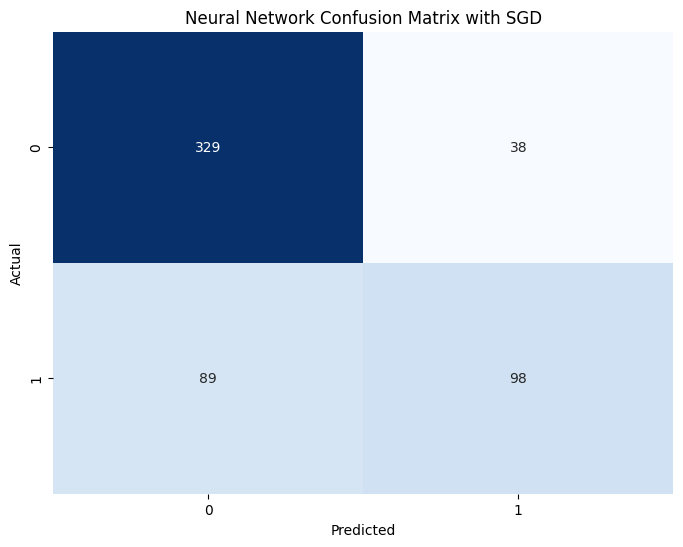

In [ ]:
nn_model_with_sgd = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_with_sgd.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_with_sgd.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

nn_pred_with_sgd = (nn_model_with_sgd.predict(X_test) > 0.5).astype("int32")

nn_conf_matrix_with_sgd = confusion_matrix(y_test, nn_pred_with_sgd)
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test,nn_pred_with_sgd)


nn_classification_report_with_sgd = classification_report(y_test, nn_pred_with_sgd)
print("Neural Network Classification Report with SGD:\n", nn_classification_report_with_sgd)
print('Neural Network - MAE       : %.2f' % mae_NN)


plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_with_sgd, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Neural Network Confusion Matrix with SGD')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


18/18 [==============================] - 0s 2ms/step
Neural Network Classification Report with Adagrad:
               precision    recall  f1-score   support

           0       0.73      0.94      0.82       367
           1       0.74      0.32      0.44       187

    accuracy                           0.73       554
   macro avg       0.73      0.63      0.63       554
weighted avg       0.73      0.73      0.69       554

Neural Network - MAE       : 0.27


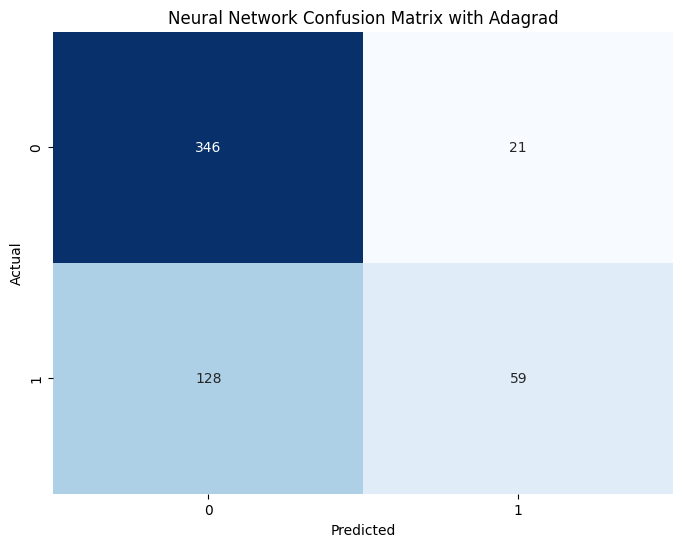

In [ ]:
nn_model_with_adagrad = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_with_adagrad.compile(optimizer='adagrad', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_with_adagrad.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

nn_pred_with_adagrad = (nn_model_with_adagrad.predict(X_test) > 0.5).astype("int32")

# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_with_adagrad)


nn_conf_matrix_with_adagrad = confusion_matrix(y_test, nn_pred_with_adagrad)

nn_classification_report_with_adagrad = classification_report(y_test, nn_pred_with_adagrad, zero_division='warn')
print("Neural Network Classification Report with Adagrad:\n", nn_classification_report_with_adagrad)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_with_adagrad, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Neural Network Confusion Matrix with Adagrad')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


18/18 [==============================] - 0s 3ms/step
Neural Network Classification Report with Adadelta:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80       367
           1       1.00      0.02      0.03       187

    accuracy                           0.67       554
   macro avg       0.83      0.51      0.42       554
weighted avg       0.78      0.67      0.54       554

Neural Network - MAE       : 0.33


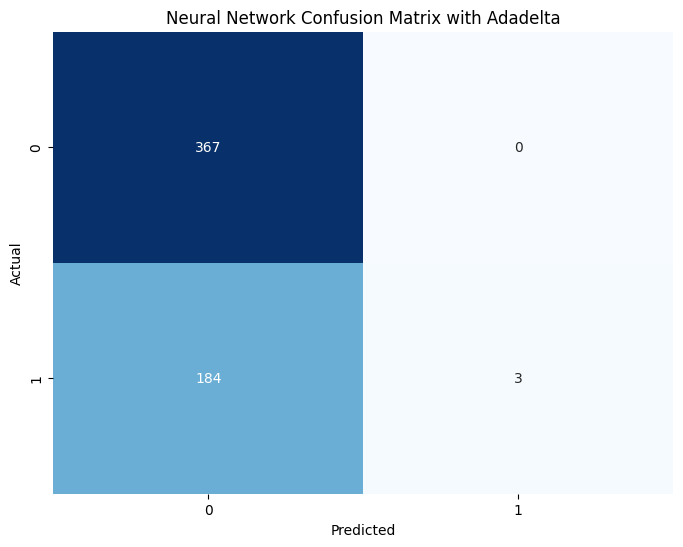

In [ ]:
nn_model_with_adadelta = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model_with_adadelta.compile(optimizer='adadelta', loss='binary_crossentropy', metrics=['accuracy'])

nn_model_with_adadelta.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

nn_pred_with_adadelta = (nn_model_with_adadelta.predict(X_test) > 0.5).astype("int32")

nn_conf_matrix_with_adadelta = confusion_matrix(y_test, nn_pred_with_adadelta)
# Calculate Mean Absolute Error
mae_NN = mean_absolute_error(y_test, nn_pred_with_adadelta)


nn_classification_report_with_adadelta = classification_report(y_test, nn_pred_with_adadelta)
print("Neural Network Classification Report with Adadelta:\n", nn_classification_report_with_adadelta)
print('Neural Network - MAE       : %.2f' % mae_NN)

plt.figure(figsize=(8, 6))
sns.heatmap(nn_conf_matrix_with_adadelta, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Neural Network Confusion Matrix with Adadelta')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 7. SVM

In [ ]:
svm_classifier = SVC(random_state=42)

svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_SVM = mean_absolute_error(y_test, y_pred)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('SVM - MAE       : %.2f' % mae_SVM)


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       367
           1       0.77      0.68      0.72       187

    accuracy                           0.82       554
   macro avg       0.81      0.79      0.80       554
weighted avg       0.82      0.82      0.82       554

Confusion Matrix:
 [[330  37]
 [ 60 127]]
Accuracy: 0.8249097472924187
Precision: 0.774390243902439
Recall: 0.679144385026738
F1 Score: 0.7236467236467237
SVM - MAE       : 0.18


***Visualisation***

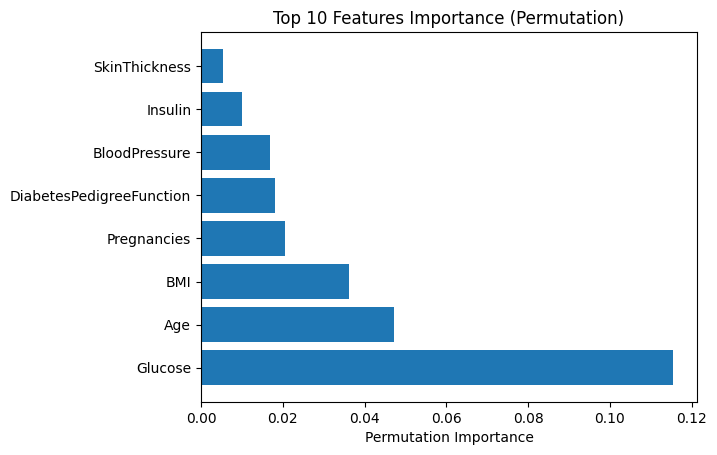

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(svm_classifier, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

plt.barh(X.columns[sorted_idx][:10], perm_importance.importances_mean[sorted_idx][:10])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Features Importance (Permutation)')
plt.show()


***Trying other test sizes***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_classifier = SVC(random_state=42)

svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate Mean Absolute Error
mae_SVM = mean_absolute_error(y_test, y_pred)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('SVM - MAE       : %.2f' % mae_SVM)

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       562
           1       0.75      0.67      0.71       269

    accuracy                           0.82       831
   macro avg       0.80      0.78      0.79       831
weighted avg       0.82      0.82      0.82       831

Confusion Matrix:
 [[502  60]
 [ 89 180]]
Accuracy: 0.8206979542719615
Precision: 0.75
Recall: 0.6691449814126395
F1 Score: 0.707269155206287
SVM - MAE       : 0.18


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

svm_classifier = SVC(random_state=42)

svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_SVM = mean_absolute_error(y_test, y_pred)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('SVM - MAE       : %.2f' % mae_SVM)

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       732
           1       0.79      0.65      0.71       376

    accuracy                           0.82      1108
   macro avg       0.81      0.78      0.79      1108
weighted avg       0.82      0.82      0.82      1108

Confusion Matrix:
 [[666  66]
 [132 244]]
Accuracy: 0.8212996389891697
Precision: 0.7870967741935484
Recall: 0.648936170212766
F1 Score: 0.7113702623906705
SVM - MAE       : 0.18


### 8. Naive Bayes

In [ ]:
#test size here is 0.4
nb_classifier = GaussianNB()

nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_NB = mean_absolute_error(y_test, y_pred)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('Naive Bayes - MAE       : %.2f' % mae_NB)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       367
           1       0.68      0.59      0.63       187

    accuracy                           0.77       554
   macro avg       0.74      0.73      0.73       554
weighted avg       0.76      0.77      0.76       554

Confusion Matrix:
 [[315  52]
 [ 76 111]]
Accuracy: 0.7689530685920578
Precision: 0.6809815950920245
Recall: 0.5935828877005348
F1 Score: 0.6342857142857142
Naive Bayes - MAE       : 0.23


***Visualisation***

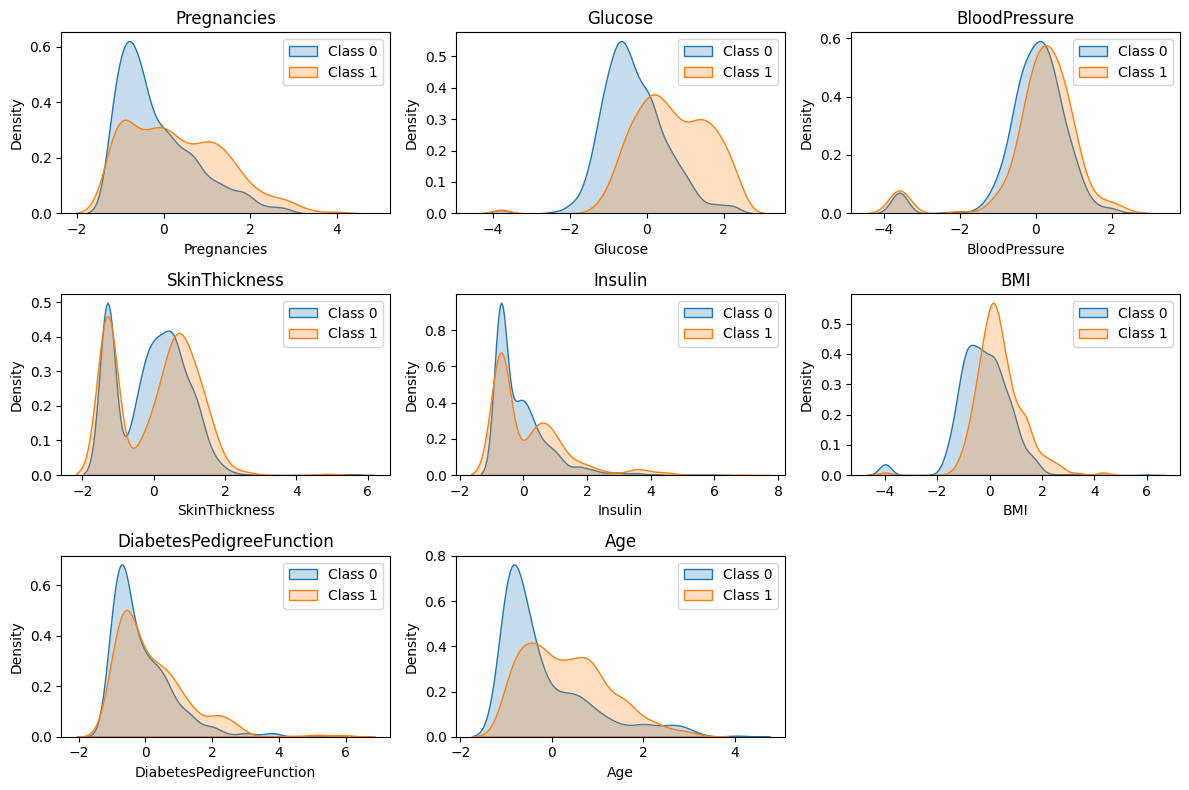

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(X.shape[1]):
    plt.subplot(3, 3, i + 1)
    sns.kdeplot(X_train[y_train == 0].iloc[:, i], label='Class 0', fill=True)
    sns.kdeplot(X_train[y_train == 1].iloc[:, i], label='Class 1', fill=True)
    plt.title(X.columns[i])
    plt.legend()
plt.tight_layout()
plt.show()


***Trying other test sizes***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_classifier = GaussianNB()

nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_NB = mean_absolute_error(y_test, y_pred)


print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('Naive Bayes - MAE       : %.2f' % mae_NB)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       367
           1       0.68      0.59      0.63       187

    accuracy                           0.77       554
   macro avg       0.74      0.73      0.73       554
weighted avg       0.76      0.77      0.76       554

Confusion Matrix:
 [[315  52]
 [ 76 111]]
Accuracy: 0.7689530685920578
Precision: 0.6809815950920245
Recall: 0.5935828877005348
F1 Score: 0.6342857142857142
Naive Bayes - MAE       : 0.23


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb_classifier = GaussianNB()

nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Calculate Mean Absolute Error
mae_NB = mean_absolute_error(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print('Naive Bayes - MAE       : %.2f' % mae_NB)

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       562
           1       0.68      0.60      0.64       269

    accuracy                           0.78       831
   macro avg       0.75      0.73      0.74       831
weighted avg       0.77      0.78      0.77       831

Confusion Matrix:
 [[484  78]
 [107 162]]
Accuracy: 0.7773766546329723
Precision: 0.675
Recall: 0.6022304832713755
F1 Score: 0.6365422396856582
Naive Bayes - MAE       : 0.22
